# 06 -- Straty hydrauliczne

Ten notebook przedstawia modele strat hydraulicznych w drodze wodnej EW:

1. **Krata wlotowa** -- wzor Kirschmera
2. **Straty tarcia w rurociagu** -- rownanie Darcy'ego-Weisbacha
3. **Straty miejscowe** -- kolana, zwezenia, zasuwy
4. **Spirala turbiny** -- straty w komorze spiralnej
5. **Rura ssawna** -- straty w dyfuzorze wylotowym
6. **Skladanie modeli** -- wybor komponentow dla konkretnej instalacji

Kazdy model jest zaimplementowany w module `src/losses.py` i moze byc wybrany
niezaleznie w zaleznosci od typu instalacji (rurociag, kanal otwarty, itp.).

---

> **Notebook OPCJONALNY** — `compute_power()` w **nb 10** ma własną definicję
> `loss_fns` (kanał otwarty z realistycznymi wymiarami), więc cały łańcuch
> integracyjny działa bez tego materiału.
>
> **Po co go czytać?** Żeby zrozumieć **dlaczego** krzywa $H_{netto}(Q)$ ma
> taki kształt — gdzie się tracą metry spadu, jak dobiera się rozmiar rurociągu
> lub kanału, kiedy lepiej kanał otwarty niż rurociąg. Bez tego notebook
> 10 jest *czarną skrzynką*.

---

## Modul `src/losses.py`

**Prompt do LLM tworzacy ten modul:**
> *"Stworz modul src/losses.py do obliczania strat hydraulicznych w drodze wodnej EW.
> Kazda funkcja przyjmuje przeplyw Q [m3/s] i zwraca strate spadku DeltaH [m].
> Funkcje: trash_rack_loss (wzor Kirschmera), pipe_friction_loss (Darcy-Weisbach
> z przyblizeniem Swamee-Jain), minor_loss (uniwersalna funkcja strat miejscowych
> uzywana dla kolan, zasuw, spirali, rury ssawnej itp.),
> total_head_loss (sumuje wybrane komponenty), net_head."*

**Funkcje w module:**
- `trash_rack_loss(Q, A_rack, ...)` -- strata na kracie wlotowej
- `pipe_friction_loss(Q, D, L, k_s)` -- tarcie w rurociagu
- `minor_loss(Q, A, xi)` -- straty miejscowe (uniwersalna — uzywana dla wszystkich strat lokalnych)
- `total_head_loss(Q, loss_components)` -- suma wybranych strat
- `net_head(H_gross, Q, loss_components)` -- spad netto

**Uwaga didaktyczna:** spirala turbiny i rura ssawna sa szczegolnymi przypadkami
strat miejscowych — uzywaja tego samego wzoru $\Delta H = \xi v^2/(2g)$ z odpowiednim $\xi$.
Wywolujemy `minor_loss()` z odpowiednia wartoscia $\xi$ dla kazdego elementu.

## Konfiguracja

**Prompt do LLM:**
> *"Napisz kod konfiguracji notebooka: zaladuj modul src/losses (trash_rack_loss,
> pipe_friction_loss, minor_loss, total_head_loss, net_head)."*

**Uzyte moduly/funkcje:** `src.losses`: trash_rack_loss, pipe_friction_loss, minor_loss, total_head_loss, net_head

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.losses import (
    trash_rack_loss,
    pipe_friction_loss,
    minor_loss,
    manning_loss,
    total_head_loss,
    net_head,
)

# Zakres demonstracji odpowiadajacy naszemu przypadkowi EW na Odrze:
# Q_total ≈ 46.8 m3/s przy 2 turbinach -> Q_design ≈ 23 m3/s na turbine.
Q_demo = np.linspace(1, 30, 200)

print('Modul zaladowany.')

Modul zaladowany.


---
## Ogolne rownanie strat hydraulicznych

Straty hydrauliczne w drodze wodnej zmniejszaja uzytkowy spad EW.
Rozrozniamy:

- **Straty liniowe** (tarciowe) -- tarcie wody o sciany rurociagu
- **Straty miejscowe** (lokalne) -- zmiany kierunku, przekroju, przeplyw przez elementy

Obie kategorie wyraza sie za pomoca **wysokosci predkosci**:

$$\Delta H = \xi \cdot \frac{v^2}{2g}$$

gdzie:
- $\xi$ -- wspolczynnik strat [-] (rozny dla kazdego elementu)
- $v = Q / A$ -- predkosc przeplywu [m/s]
- $g = 9.81$ m/s$^2$

**Spad netto** to spad brutto pomniejszony o sume strat:

$$H_{netto} = H_{brutto} - \sum_i \Delta H_i$$

### Reguly wymiarowania komponentow

Straty rosna z **kwadratem predkosci** ($\xi v^2/(2g)$), wiec dobre wymiarowanie jest kluczowe. Typowe predkosci projektowe dla *rozsadnych* strat:

| Komponent | Typowa predkosc v | Komentarz |
|-----------|-------------------|-----------|
| Krata wlotowa | 0.5--1.5 m/s | Wyzsze → zatkanie, vibracje |
| Rurociag | 3--5 m/s | Optimum koszt rurociagu vs straty |
| Kanal otwarty | 0.5--2 m/s | Manning; niska predkosc = niskie straty |
| Spirala turbiny | 5--8 m/s | Projektowana przez producenta |
| Wirnik (wyjscie) | 4--10 m/s | Z D1 wirnika i Q |

**Reguła:** sprawdz predkosci na **kazdym** komponencie. Jesli sumaryczne straty przekraczaja 5--10% spadu brutto, prawdopodobnie cos jest niedostarczone.

Dla naszego EW na niskim spadzie ($H \approx 6$ m, $Q_{design} \approx 23$ m³/s na turbine):
- **Krotki rurociag** $D = 3$ m, $L = 10$--$30$ m (v ≈ 3 m/s, strata < 5 cm) — **lub kanal otwarty**
- $A_{kraty} \geq 20$ m² (v < 1.2 m/s)
- $A_{spirali} \approx 3.5$ m² (v ≈ 6.6 m/s)
- $A_{wirnika}$ ≈ 6 m² (z $D_1 \approx 2.8$ m dla Kaplana)

**Wazna uwaga dla niskospadowych elektrowni przeplywowych (run-of-river, $H<10$ m):** dlugi rurociag jest **nieekonomiczny** — same straty tarcia zjedlyby duza czesc spadu. Stosujemy **krotki rurociag (L < 30 m)** lub **kanal otwarty** (Manning) z wlotem bezposrednio do spirali turbiny.

---
## Krok 1: Krata wlotowa (trash rack)

Krata wlotowa chroni turbine przed zanieczyszczeniami.
Straty obliczamy wzorem **Kirschmera**:

$$\Delta H_{krata} = \beta \cdot \left(\frac{s}{b}\right)^{4/3} \cdot \sin\alpha \cdot \frac{v^2}{2g}$$

gdzie:
- $\beta$ -- wspolczynnik ksztaltu pretow:
  - 2.42 -- prety prostokatne
  - 1.79 -- prety kolowe
  - 1.67 -- prety oplywowe
- $s$ -- szerokosc preta [m]
- $b$ -- przeswit miedzy pretami [m]
- $\alpha$ -- kat nachylenia kraty [deg] (90° = pionowa)
- $v$ -- predkosc naplywu na krate [m/s]

**Prompt do LLM:**
> *"Napisz kod ktory pokaze straty na kracie wlotowej dla roznych ksztaltow pretow
> (prostokatne, kolowe, oplyniowe) w funkcji przeplywu Q. Uzyj A_rack=4m2,
> s=12mm, b=50mm. Narysuj wykres plotly."*

**Uzyte funkcje:** `src.losses.trash_rack_loss()`

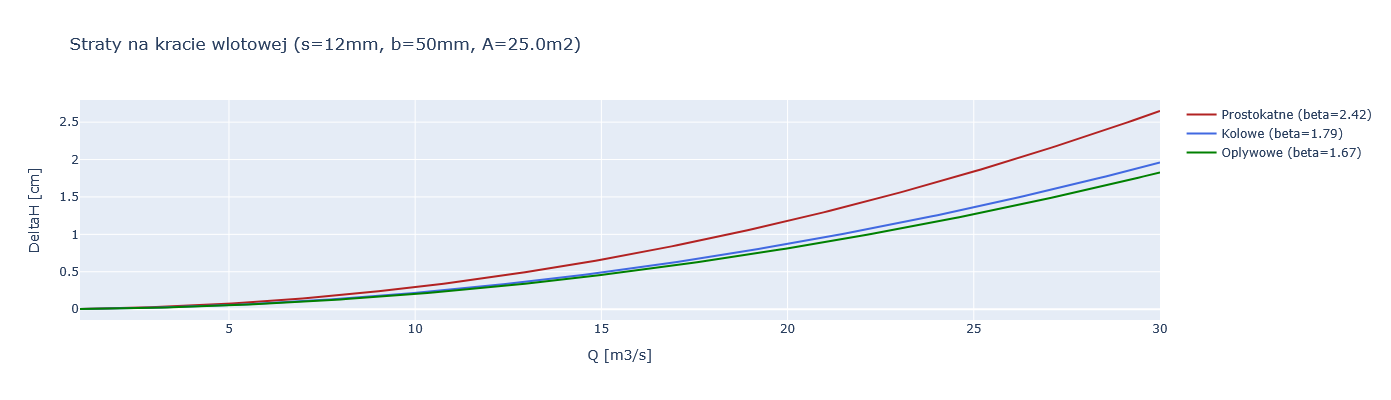

Strata na kracie przy Q=23.0 m3/s (v=0.92 m/s): 0.0156 m = 1.56 cm


In [2]:
# Krata o powierzchni ~ 25 m2 (v < 1 m/s przy Q_design)
A_rack = 25.0
s = 0.012
b = 0.050

shapes = [
    ('Prostokatne (beta=2.42)', 2.42, 'firebrick'),
    ('Kolowe (beta=1.79)', 1.79, 'royalblue'),
    ('Oplywowe (beta=1.67)', 1.67, 'green'),
]

fig = go.Figure()
for label, beta, color in shapes:
    dH = trash_rack_loss(Q_demo, A_rack, bar_width=s, bar_spacing=b, bar_shape_coeff=beta)
    fig.add_trace(go.Scatter(x=Q_demo, y=dH * 100, mode='lines',
        name=label, line=dict(color=color, width=2)))

fig.update_layout(
    title=f'Straty na kracie wlotowej (s={s*1000:.0f}mm, b={b*1000:.0f}mm, A={A_rack}m2)',
    xaxis_title='Q [m3/s]', yaxis_title='DeltaH [cm]',
    height=400, hovermode='x unified',
)
fig.show()

Q_typ = 23.0
v_typ = Q_typ / A_rack
dH_typ = trash_rack_loss(Q_typ, A_rack, bar_width=s, bar_spacing=b)
print(f'Strata na kracie przy Q={Q_typ} m3/s (v={v_typ:.2f} m/s): '
      f'{dH_typ:.4f} m = {dH_typ*100:.2f} cm')

---
## Krok 2: Straty tarcia w rurociagu (Darcy-Weisbach)

Dla przeplywu w rurociagu straty tarcia obliczamy rownaniem **Darcy'ego-Weisbacha**:

$$\Delta H_f = f \cdot \frac{L}{D} \cdot \frac{v^2}{2g}$$

gdzie wspolczynnik tarcia $f$ zalezy od liczby Reynoldsa i chropowatosc sciany.
Uzywamy przyblizenia **Swamee-Jain** (jawne, nie wymaga iteracji):

$$f = \frac{0.25}{\left[\log_{10}\left(\frac{k_s}{3.7D} + \frac{5.74}{Re^{0.9}}\right)\right]^2}$$

Typowe chropowatosc $k_s$:
- Rura stalowa nowa: 0.05 mm
- Rura stalowa uzywana: 0.1--1.0 mm
- Beton gladki: 0.3--1.0 mm
- Beton szorstki: 1.0--3.0 mm

**Prompt do LLM:**
> *"Napisz kod ktory pokaze straty tarcia w rurociagu dla roznych srednic
> (D=1.0, 1.5, 2.0 m) i stalej dlugosci L=100m. Narysuj wykres."*

**Uzyte funkcje:** `src.losses.pipe_friction_loss()`

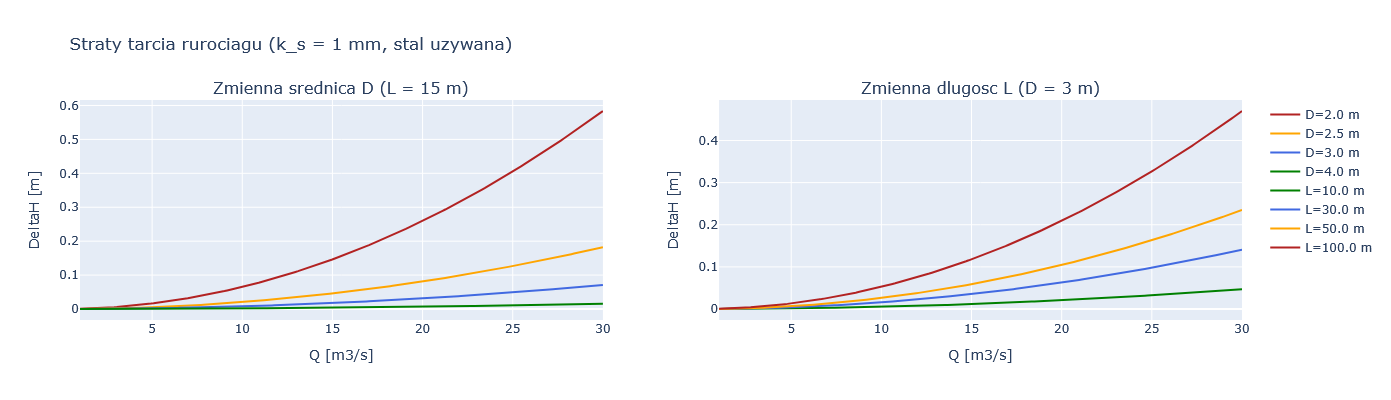

Przy Q=23.0 m3/s (Q_design na turbine):
D, L            v [m/s]   DeltaH [m]   % H_brutto (6 m)
D=2.0m L=10m       7.32       0.2289               3.81
D=2.0m L=30m       7.32       0.6866              11.44
D=2.0m L=50m       7.32       1.1443              19.07
D=2.5m L=10m       4.69       0.0715               1.19
D=2.5m L=30m       4.69       0.2145               3.57
D=2.5m L=50m       4.69       0.3575               5.96
D=3.0m L=10m       3.25       0.0277               0.46
D=3.0m L=30m       3.25       0.0830               1.38
D=3.0m L=50m       3.25       0.1383               2.31
D=4.0m L=10m       1.83       0.0062               0.10
D=4.0m L=30m       1.83       0.0186               0.31
D=4.0m L=50m       1.83       0.0310               0.52


In [3]:
# Parametryczna analiza: srednica D i dlugosc L
k_s = 0.001

fig = make_subplots(rows=1, cols=2, subplot_titles=[
    'Zmienna srednica D (L = 15 m)', 'Zmienna dlugosc L (D = 3 m)'])

# Lewy panel: rozne D, stale L=15m
for D, color in [(2.0, 'firebrick'), (2.5, 'orange'), (3.0, 'royalblue'), (4.0, 'green')]:
    dH = pipe_friction_loss(Q_demo, D=D, L=15.0, k_s=k_s)
    fig.add_trace(go.Scatter(x=Q_demo, y=dH, mode='lines',
        name=f'D={D} m', line=dict(color=color, width=2)), row=1, col=1)

# Prawy panel: rozne L, stale D=3m
for L, color in [(10.0, 'green'), (30.0, 'royalblue'), (50.0, 'orange'), (100.0, 'firebrick')]:
    dH = pipe_friction_loss(Q_demo, D=3.0, L=L, k_s=k_s)
    fig.add_trace(go.Scatter(x=Q_demo, y=dH, mode='lines',
        name=f'L={L} m', line=dict(color=color, width=2)), row=1, col=2)

fig.update_xaxes(title_text='Q [m3/s]')
fig.update_yaxes(title_text='DeltaH [m]')
fig.update_layout(height=400, hovermode='x unified',
    title='Straty tarcia rurociagu (k_s = 1 mm, stal uzywana)')
fig.show()

# Tabelka przy Q_design = 23 m3/s
Q_typ = 23.0
print(f'Przy Q={Q_typ} m3/s (Q_design na turbine):')
print(f'{"D, L":12s} {"v [m/s]":>10s} {"DeltaH [m]":>12s} {"% H_brutto (6 m)":>18s}')
for D in [2.0, 2.5, 3.0, 4.0]:
    for L in [10.0, 30.0, 50.0]:
        dH = float(pipe_friction_loss(Q_typ, D=D, L=L, k_s=k_s))
        v = Q_typ / (np.pi * D**2 / 4)
        print(f'D={D}m L={L:.0f}m'.ljust(12),
              f'{v:10.2f} {dH:12.4f} {dH/6*100:18.2f}')

---
## Krok 2b: Alternatywa — kanal otwarty (Manning)

Dla niskospadowych elektrowni przeplywowych dlugi rurociag jest nieekonomiczny (straty tarcia rosną z $v^2$, a $v$ jest wysokie w rurze). Naturalna alternatywa to **kanal otwarty** (ang. *headrace canal*): wode prowadzimy z ujecia do hali maszyn kanalem prostokatnym lub trapezowym.

Straty tarcia w kanale otwartym: **wzor Manninga**

$$\Delta H = \left(\dfrac{n \cdot v}{R^{2/3}}\right)^2 \cdot L$$

gdzie:
- $n$ — wspolczynnik szorstkosci Manninga (beton gladki 0.013, ziemia/trawa 0.025--0.035)
- $v = Q/A$ — predkosc w kanale
- $A$ — pole przekroju (np. $b \cdot h$ dla prostokatnego)
- $R$ — promien hydrauliczny $= A/P$ ($P$ = obwod zwilzony)
- $L$ — dlugosc kanalu

**Zaleta kanalu**: $v$ jest **duzo mniejsze** (typowo 0.5--2 m/s), wiec straty sa rzedy wielkosci mniejsze. Wada: szersza zabudowa, ekspozycja na warunki atmosferyczne, trudnosci w zimie (lod).

**Prompt do LLM:**
> *"Policz straty Manninga dla kanalu betonowego (n=0.013) o szerokosci dna 8 m, > glebokosci 2 m, dlugosci 30 m. Porownaj z rurociagiem D=3m, L=30m przy tym samym Q."*

**Uzyte funkcje:** `numpy` (Manning eq policzony inline — jeden wzor).

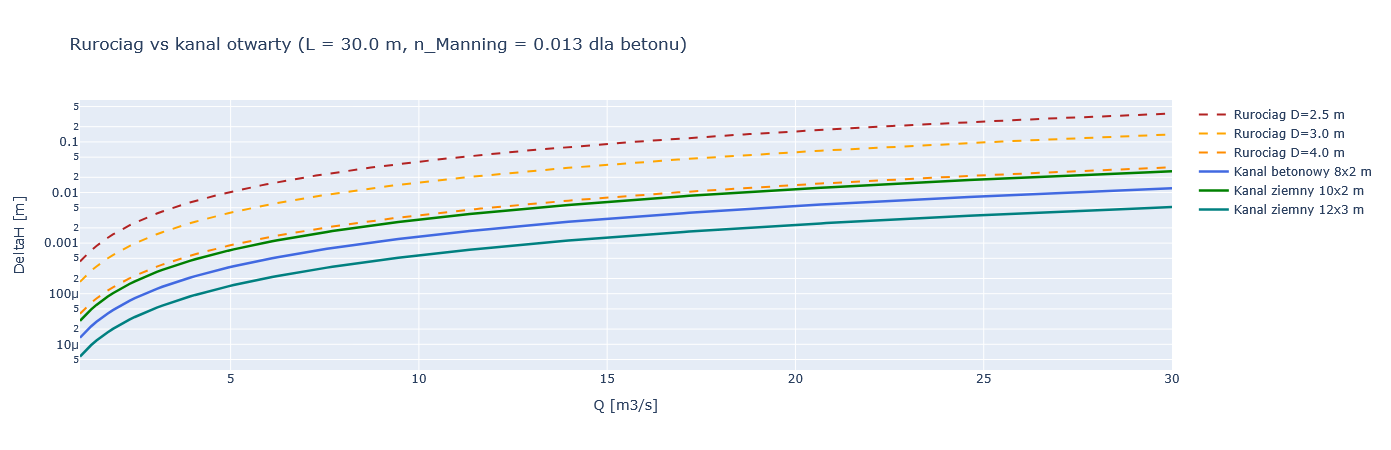

Przy Q=23.0 m3/s, L = 30.0 m:
  Rurociag D=2.5 m: v=4.69 m/s, dH = 21.45 cm
  Rurociag D=3.0 m: v=3.25 m/s, dH = 8.30 cm
  Rurociag D=4.0 m: v=1.83 m/s, dH = 1.86 cm
  Kanal betonowy 8x2 m: v=1.44 m/s, dH = 7.14 mm
  Kanal ziemny 10x2 m: v=1.15 m/s, dH = 15.41 mm
  Kanal ziemny 12x3 m: v=0.64 m/s, dH = 3.04 mm

Wniosek: w kanale otwartym predkosc jest 3-5x mniejsza, a strata tarcia ~ 100x mniejsza.
Dlatego dla niskospadowych elektrowni przeplywowych preferujemy kanal lub bardzo krotki rurociag.


In [4]:
# Porownanie: rurociag vs kanal otwarty, dla tej samej dlugosci L=30 m i Q
L_compare = 30.0
fig = go.Figure()

# Rurociag: kilka srednic
for D, color in [(2.5, 'firebrick'), (3.0, 'orange'), (4.0, 'darkorange')]:
    dH = pipe_friction_loss(Q_demo, D=D, L=L_compare, k_s=0.001)
    fig.add_trace(go.Scatter(x=Q_demo, y=dH, mode='lines',
        name=f'Rurociag D={D} m', line=dict(color=color, width=2, dash='dash')))

# Kanal: trzy warianty (beton gladki 8x2, ziemia 10x2, ziemia 12x3)
configs = [
    ('Kanal betonowy 8x2 m', 8.0, 2.0, 0.013, 'royalblue'),
    ('Kanal ziemny 10x2 m', 10.0, 2.0, 0.025, 'green'),
    ('Kanal ziemny 12x3 m', 12.0, 3.0, 0.025, 'teal'),
]
for label, b, h, n_m, color in configs:
    dH = manning_loss(Q_demo, b, h, L_compare, n_manning=n_m)
    fig.add_trace(go.Scatter(x=Q_demo, y=dH, mode='lines',
        name=label, line=dict(color=color, width=2.5)))

fig.update_layout(
    title=f'Rurociag vs kanal otwarty (L = {L_compare} m, n_Manning = 0.013 dla betonu)',
    xaxis_title='Q [m3/s]', yaxis_title='DeltaH [m]',
    yaxis_type='log',
    height=450, hovermode='x unified',
)
fig.show()

# Liczby przy Q_design = 23 m3/s
Q_typ = 23.0
print(f'Przy Q={Q_typ} m3/s, L = {L_compare} m:')
for D in [2.5, 3.0, 4.0]:
    dH = float(pipe_friction_loss(Q_typ, D=D, L=L_compare, k_s=0.001))
    v = Q_typ / (np.pi * D**2 / 4)
    print(f'  Rurociag D={D} m: v={v:.2f} m/s, dH = {dH*100:.2f} cm')
for label, b, h, n_m, _ in configs:
    dH = float(manning_loss(Q_typ, b, h, L_compare, n_manning=n_m))
    A = b*h; v = Q_typ/A
    print(f'  {label}: v={v:.2f} m/s, dH = {dH*1000:.2f} mm')
print()
print('Wniosek: w kanale otwartym predkosc jest 3-5x mniejsza, a strata tarcia ~ 100x mniejsza.')
print('Dlatego dla niskospadowych elektrowni przeplywowych preferujemy kanal lub bardzo krotki rurociag.')

---
## Krok 3: Straty miejscowe

Straty miejscowe powstaja przy kazdej zmianie kierunku lub przekroju:

$$\Delta H_{lok} = \xi \cdot \frac{v^2}{2g}$$

Typowe wspolczynniki $\xi$:

| Element | $\xi$ |
|---------|-------|
| Wlot ostrokrawedzisty | 0.5 |
| Wlot zaokraglony | 0.1--0.2 |
| Kolano 90° (r/D=1) | 0.5--1.0 |
| Kolano 90° (r/D=3) | 0.2--0.3 |
| Zasuwa (otwarta) | 0.1--0.2 |
| Zasuwa motylkowa | 0.2--0.5 |
| Nagle zwezenie | 0.5·(1-A2/A1) |
| Nagle rozszerzenie | (1-A1/A2)² |
| Wylot z rury | 1.0 |

**Prompt do LLM:**
> *"Napisz kod ktory pokaze straty miejscowe dla typowych elementow
> (wlot zaokraglony, kolano, zasuwa) przy przeplywach 1-200 m3/s
> i przekroju A=1.77 m2 (rura D=1.5m). Narysuj wykres slupkowy
> sumy strat przy Q=50 m3/s."*

**Uzyte funkcje:** `src.losses.minor_loss()`

Straty miejscowe przy Q=23.0 m3/s, D=3.0m (A=7.07 m2, v=3.25 m/s):
  Wlot zaokraglony               (xi=0.15): 0.0809 m = 8.09 cm
  Kolano 90° (r/D=2)             (xi=0.25): 0.1349 m = 13.49 cm
  Kolano 90° (r/D=2)             (xi=0.25): 0.1349 m = 13.49 cm
  Zasuwa motylkowa               (xi=0.30): 0.1619 m = 16.19 cm
  SUMA                                   : 0.5126 m = 51.26 cm


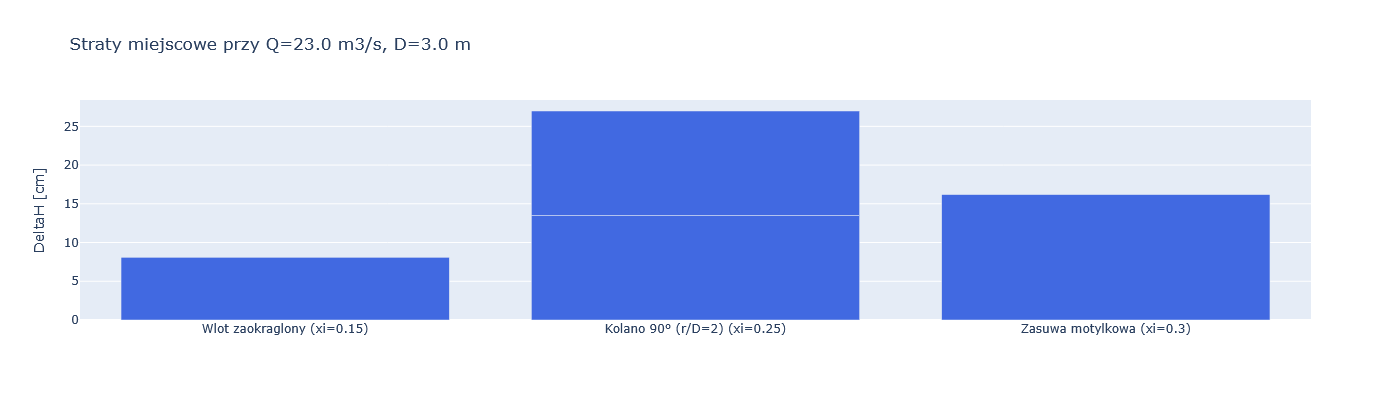

In [5]:
D_pipe = 3.0
A_pipe = np.pi * D_pipe**2 / 4

elements = [
    ('Wlot zaokraglony', 0.15),
    ('Kolano 90° (r/D=2)', 0.25),
    ('Kolano 90° (r/D=2)', 0.25),
    ('Zasuwa motylkowa', 0.3),
]

Q_test = 23.0
v_pipe = Q_test / A_pipe
print(f'Straty miejscowe przy Q={Q_test} m3/s, D={D_pipe}m '
      f'(A={A_pipe:.2f} m2, v={v_pipe:.2f} m/s):')
names, values = [], []
for name, xi in elements:
    dH = minor_loss(Q_test, A_pipe, xi)
    print(f'  {name:30s} (xi={xi:.2f}): {dH:.4f} m = {dH*100:.2f} cm')
    names.append(f'{name} (xi={xi})')
    values.append(float(dH))

print(f'  {"SUMA":30s}         : {sum(values):.4f} m = {sum(values)*100:.2f} cm')

fig = go.Figure(go.Bar(x=names, y=[v*100 for v in values], marker_color='royalblue'))
fig.update_layout(
    title=f'Straty miejscowe przy Q={Q_test} m3/s, D={D_pipe} m',
    yaxis_title='DeltaH [cm]', height=400,
)
fig.show()

---
## Krok 4: Spirala turbiny (komora spiralna)

Komora spiralna doprowadza wode do wirnika turbiny rownomaiernie
po obwodzie. Straty zaleza od jakosci wykonania:

$$\Delta H_{spirala} = \xi_{spirala} \cdot \frac{v_{wlot}^2}{2g}$$

Typowe $\xi$:
- Spirala dobrze zaprojektowana: 0.05--0.10
- Prosta komora: 0.10--0.20

**Prompt do LLM:**
> *"Napisz kod ktory pokaze straty w spirali dla xi=0.05, 0.10, 0.20.
> Uzyj `minor_loss()` z A_inlet jako polem wlotu spirali."*

**Uzyte funkcje:** `src.losses.minor_loss()` (spirala = strata miejscowa z $\xi_{spirala}$)

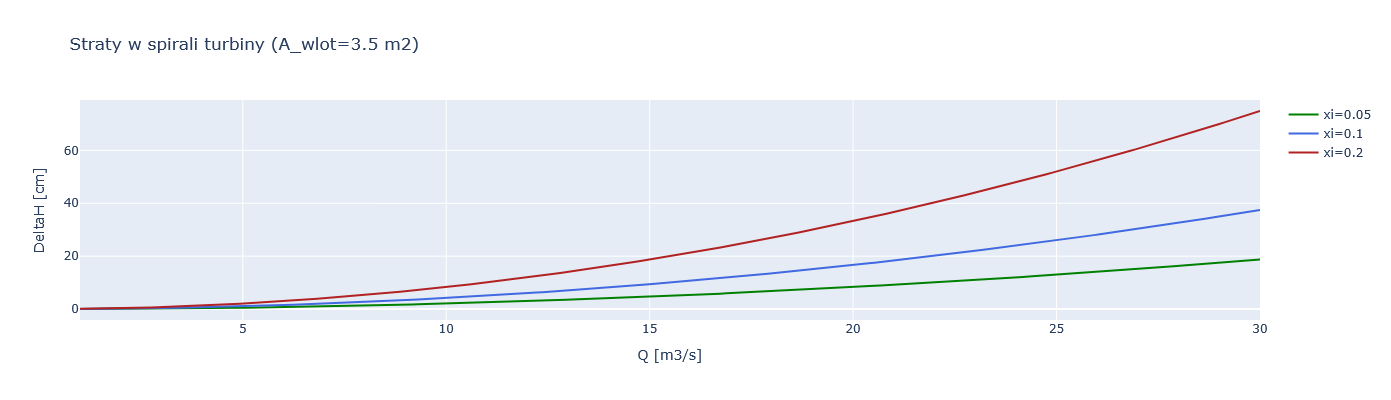

In [6]:
A_spiral = 3.5

fig = go.Figure()
for xi, color in [(0.05, 'green'), (0.10, 'royalblue'), (0.20, 'firebrick')]:
    dH = minor_loss(Q_demo, A_spiral, xi=xi)
    fig.add_trace(go.Scatter(x=Q_demo, y=dH*100, mode='lines',
        name=f'xi={xi}', line=dict(color=color, width=2)))

fig.update_layout(
    title=f'Straty w spirali turbiny (A_wlot={A_spiral} m2)',
    xaxis_title='Q [m3/s]', yaxis_title='DeltaH [cm]',
    height=400, hovermode='x unified',
)
fig.show()

---
## Krok 5: Rura ssawna (draft tube)

Rura ssawna to dyfuzor ponizej wirnika. Spowalnia wode i odzyskuje czesc
energii kinetycznej. Straty odnosimy do predkosci na wlocie (wyjscie z wirnika):

$$\Delta H_{rura} = \xi_{rura} \cdot \frac{v_{wlot}^2}{2g}$$

Typowe $\xi$:
- Rura stozikowa prosta: 0.15--0.25
- Rura kolanowa: 0.25--0.40
- Brak rury ssawnej (wylot z turbiny): $\xi \approx 1.0$

**Uwaga:** rura ssawna **zmniejsza** straty ogolne. Bez niej cala energia kinetyczna
za wirnikiem jest tracona ($\xi=1.0$). Dobra rura ssawna redukuje to do $\xi=0.2$.

**Prompt do LLM:**
> *"Porownaj straty: z rura ssawna (xi=0.25) vs bez rury (xi=1.0),
> przy A_inlet=0.8m2. Pokaz ile energii odzyskuje rura.
> Uzyj `minor_loss()` z A_inlet jako polem wyjscia z wirnika."*

**Uzyte funkcje:** `src.losses.minor_loss()` (rura ssawna = strata miejscowa z $\xi_{rura}$ odniesiona do predkosci wlotu)

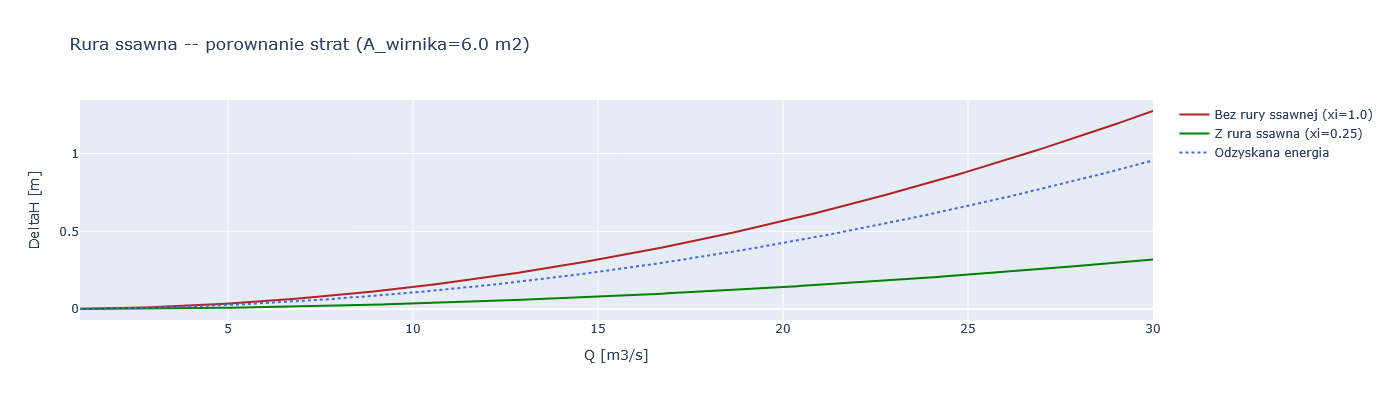

Przy Q=23.0 m3/s (v_wirnika=3.83 m/s):
  Bez rury ssawnej (xi=1.0): 0.749 m
  Z rura ssawna (xi=0.25):   0.187 m


In [7]:
# Wirnik Kaplana z D1 ≈ 2.8 m daje A_wirnika ≈ 6 m².
A_runner_exit = 6.0

dH_with = minor_loss(Q_demo, A_runner_exit, xi=0.25)
dH_without = minor_loss(Q_demo, A_runner_exit, xi=1.0)

fig = go.Figure()
fig.add_trace(go.Scatter(x=Q_demo, y=dH_without, mode='lines',
    name='Bez rury ssawnej (xi=1.0)', line=dict(color='firebrick', width=2)))
fig.add_trace(go.Scatter(x=Q_demo, y=dH_with, mode='lines',
    name='Z rura ssawna (xi=0.25)', line=dict(color='green', width=2)))
fig.add_trace(go.Scatter(x=Q_demo, y=dH_without - dH_with, mode='lines',
    name='Odzyskana energia', line=dict(color='royalblue', width=2, dash='dot')))
fig.update_layout(
    title=f'Rura ssawna -- porownanie strat (A_wirnika={A_runner_exit} m2)',
    xaxis_title='Q [m3/s]', yaxis_title='DeltaH [m]',
    height=400, hovermode='x unified',
)
fig.show()

Q_test = 23.0
v_runner = Q_test / A_runner_exit
print(f'Przy Q={Q_test} m3/s (v_wirnika={v_runner:.2f} m/s):')
print(f'  Bez rury ssawnej (xi=1.0): {float(minor_loss(Q_test, A_runner_exit, xi=1.0)):.3f} m')
print(f'  Z rura ssawna (xi=0.25):   {float(minor_loss(Q_test, A_runner_exit, xi=0.25)):.3f} m')

---
## Krok 6: Skladanie modeli -- wybor komponentow

Dla konkretnej instalacji student **recznie wybiera** ktore komponenty strat
dotycza jego przypadku. Kazdy komponent to funkcja `Q -> DeltaH`.

**Przyklady konfiguracji:**

| Typ instalacji | Komponenty |
|----------------|------------|
| Rurociag + turbina Kaplana | krata, tarcie rury, kolana, zasuwa, spirala, rura ssawna |
| Kanal otwarty + turbina | krata, spirala, rura ssawna |
| Derivacyjna z dlugim rurociagiem | krata, tarcie (dlugi), wiele kolan, zasuwa, spirala, rura ssawna |

**Prompt do LLM:**
> *"Napisz kod ktory zlozy model strat dla przykladowej instalacji rurociagowej:
> krata + rurociag (D=1.5m, L=50m) + 2 kolana + zasuwa + spirala + rura ssawna.
> Oblicz spad netto H_net(Q) i narysuj wykres H_gross vs H_net."*

**Uzyte funkcje:** `src.losses.total_head_loss()`, `src.losses.net_head()`

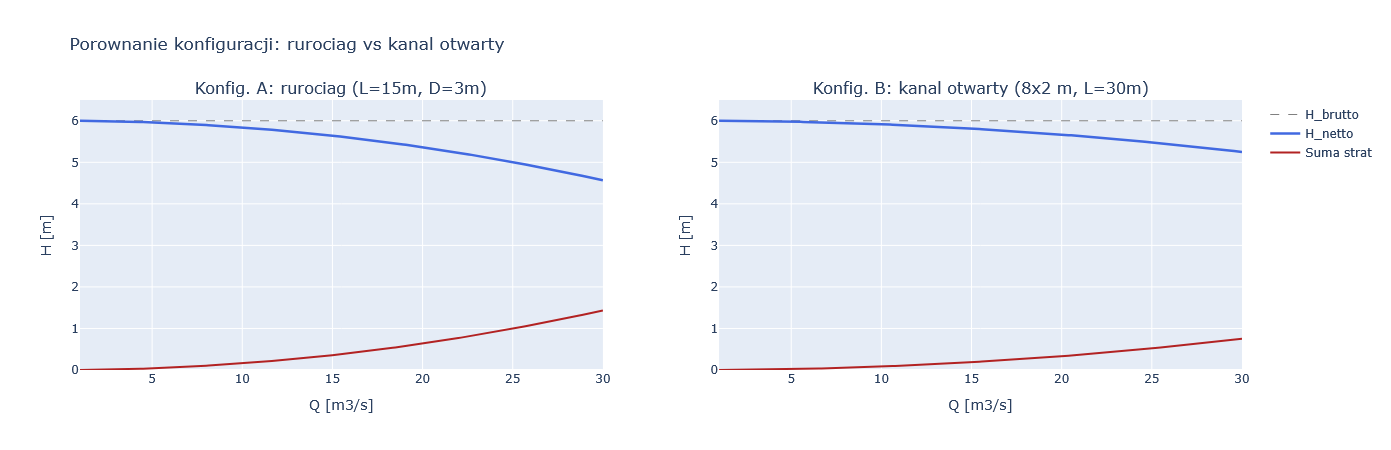

Przy Q = 23.0 m3/s (Q_design na turbine, H_brutto = 6.0 m):
  Konfig. A (rurociag):     dH = 0.842 m (14.0% H_brutto)
  Konfig. B (kanal otwarty): dH = 0.441 m (7.3% H_brutto)

Roznica strat: 40.2 cm na korzysc kanalu.
Wybor: kanal otwarty wygrywa hydrauliczne, ale ma wyzsze koszty civil i ryzyka eksploatacyjne.


In [8]:
# === DWIE KONFIGURACJE EW DO PORONANIA ===
# Wymiary dopasowane do Q_design ≈ 23 m3/s na turbine.

D_pipe = 3.0
A_pipe = np.pi * D_pipe**2 / 4

# Konfiguracja A: krotki rurociag (typowa dla starych elektrowni)
loss_fns_pipe = [
    lambda Q: trash_rack_loss(Q, A_rack=25.0, bar_width=0.012, bar_spacing=0.05),
    lambda Q: pipe_friction_loss(Q, D=D_pipe, L=15.0, k_s=0.001),  # KROTKI rurociag
    lambda Q: minor_loss(Q, A_pipe, xi=0.15),     # wlot zaokraglony
    lambda Q: minor_loss(Q, A_pipe, xi=0.25),     # kolano
    lambda Q: minor_loss(Q, A_pipe, xi=0.3),      # zasuwa
    lambda Q: minor_loss(Q, A=3.5, xi=0.10),      # spirala
    lambda Q: minor_loss(Q, A=6.0, xi=0.25),      # rura ssawna
]

# Konfiguracja B: kanal otwarty (typowa dla nowszych niskospadowych EW)
loss_fns_channel = [
    lambda Q: trash_rack_loss(Q, A_rack=25.0, bar_width=0.012, bar_spacing=0.05),
    lambda Q: manning_loss(Q, b=8.0, h=2.0, L=30.0, n_manning=0.013),  # kanal betonowy
    lambda Q: minor_loss(Q, A=16.0, xi=0.10),     # wlot do kanalu/zwezki
    lambda Q: minor_loss(Q, A=3.5, xi=0.10),      # spirala
    lambda Q: minor_loss(Q, A=6.0, xi=0.25),      # rura ssawna
]

H_gross = 6.0
Q_range = np.linspace(1, 30, 200)

dH_pipe = total_head_loss(Q_range, loss_fns_pipe)
dH_chan = total_head_loss(Q_range, loss_fns_channel)
Hn_pipe = net_head(H_gross, Q_range, loss_fns_pipe)
Hn_chan = net_head(H_gross, Q_range, loss_fns_channel)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['Konfig. A: rurociag (L=15m, D=3m)',
                    'Konfig. B: kanal otwarty (8x2 m, L=30m)'])
for col, (dH, Hn, title) in enumerate([
    (dH_pipe, Hn_pipe, 'A'),
    (dH_chan, Hn_chan, 'B'),
], start=1):
    fig.add_trace(go.Scatter(x=Q_range, y=np.full_like(Q_range, H_gross),
        name='H_brutto', line=dict(color='gray', dash='dash', width=1),
        showlegend=(col == 1)), row=1, col=col)
    fig.add_trace(go.Scatter(x=Q_range, y=Hn, name='H_netto',
        line=dict(color='royalblue', width=2.5),
        showlegend=(col == 1)), row=1, col=col)
    fig.add_trace(go.Scatter(x=Q_range, y=dH, name='Suma strat',
        line=dict(color='firebrick', width=2),
        showlegend=(col == 1)), row=1, col=col)
fig.update_xaxes(title_text='Q [m3/s]')
fig.update_yaxes(title_text='H [m]', range=[0, H_gross + 0.5])
fig.update_layout(height=450, hovermode='x unified',
    title='Porownanie konfiguracji: rurociag vs kanal otwarty')
fig.show()

# Liczby przy Q_design
Q_test = 23.0
dH_A = float(total_head_loss(Q_test, loss_fns_pipe))
dH_B = float(total_head_loss(Q_test, loss_fns_channel))
print(f'Przy Q = {Q_test} m3/s (Q_design na turbine, H_brutto = {H_gross} m):')
print(f'  Konfig. A (rurociag):     dH = {dH_A:.3f} m ({dH_A/H_gross*100:.1f}% H_brutto)')
print(f'  Konfig. B (kanal otwarty): dH = {dH_B:.3f} m ({dH_B/H_gross*100:.1f}% H_brutto)')
print()
print(f'Roznica strat: {(dH_A - dH_B)*100:.1f} cm na korzysc kanalu.')
print('Wybor: kanal otwarty wygrywa hydrauliczne, ale ma wyzsze koszty civil i ryzyka eksploatacyjne.')

# Dla dalszej analizy uzywamy konfiguracji B (krotki kanal) jako reprezentatywnej:
loss_fns = loss_fns_channel

**Prompt do LLM:**
> *"Narysuj wykres slupkowy rozkladu strat po komponentach przy Q=50 m3/s.
> Pokaz udzial procentowy kazdego elementu."*

**Uzyte funkcje:** `loss_fns` zdefiniowane wyzej (lista `Q -> dH` na komponent)

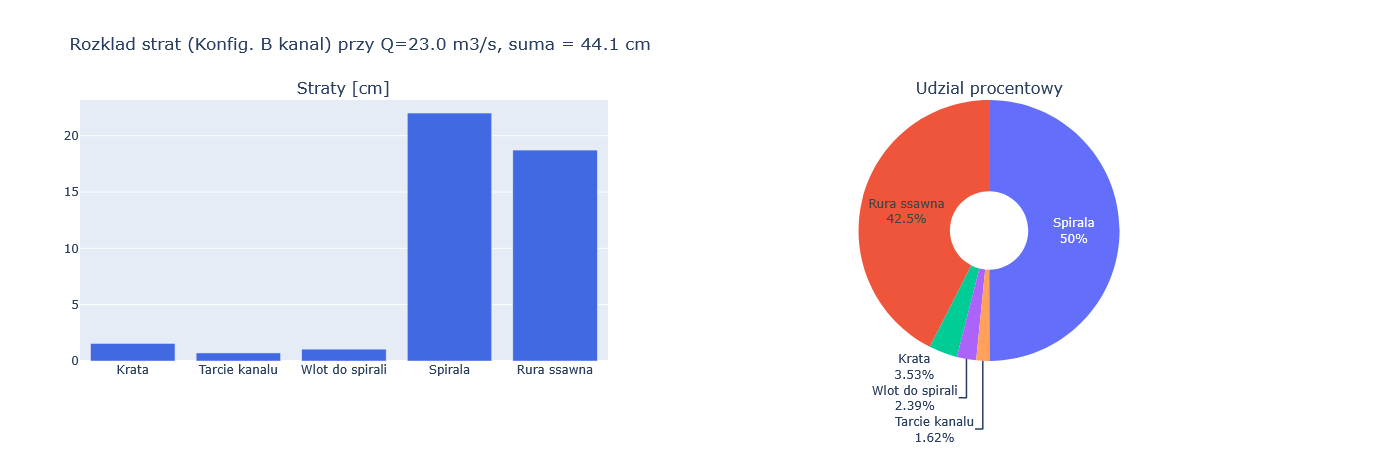

In [9]:
Q_test = 23.0
component_names = [
    'Krata', 'Tarcie kanalu',
    'Wlot do spirali', 'Spirala', 'Rura ssawna',
]
component_losses = [float(fn(Q_test)) for fn in loss_fns]  # loss_fns = channel config
total = sum(component_losses)


fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'bar'}, {'type': 'pie'}]],
    subplot_titles=['Straty [cm]', 'Udzial procentowy'])

fig.add_trace(go.Bar(x=component_names, y=[v*100 for v in component_losses],
    marker_color='royalblue'), row=1, col=1)
fig.add_trace(go.Pie(labels=component_names, values=component_losses,
    textinfo='label+percent', hole=0.3), row=1, col=2)
fig.update_layout(
    title=f'Rozklad strat (Konfig. B kanal) przy Q={Q_test} m3/s, suma = {total*100:.1f} cm',
    height=450, showlegend=False,
)
fig.show()

---
## Podsumowanie

W tym notebooku przedstawiono modele strat hydraulicznych:

| Model | Wzor | Funkcja |
|-------|------|---------|
| Krata wlotowa | Kirschmer | `losses.trash_rack_loss()` |
| Tarcie rurociagu | Darcy-Weisbach + Swamee-Jain | `losses.pipe_friction_loss()` |
| Straty miejscowe (kolana, zasuwy, spirala, rura ssawna) | $\xi \cdot v^2/(2g)$ | `losses.minor_loss()` |

Modele sklada sie w liste `loss_fns` odpowiednia dla danego typu instalacji.
Funkcja `net_head(H_gross, Q, loss_fns)` oblicza spad netto.

**Uwaga didaktyczna:** spirala turbiny i rura ssawna nie maja osobnych funkcji
w module — uzywaja `minor_loss(Q, A, xi)` z odpowiednim wspolczynnikiem (tabela powyzej).
To podkresla, ze wszystkie straty lokalne maja te sama strukture: $\xi \cdot v^2/(2g)$.

**Lista `loss_fns` zostanie przekazana do notebooka 10 (obliczenia produkcji).**

**Dalej:** notebook 07 -- model sprawnosci turbiny